## Собираем сегменты

In [21]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import json
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

from itertools import combinations
from IPython.display import display
from itertools import combinations
from datetime import datetime



In [8]:
current_year = datetime.now().year
df_merged = pd.read_csv('data/processed/processed_task1_total_liquidity.csv')
# ==========================================
# 1. БИННИНГ ЧИСЛОВЫХ ПРИЗНАКОВ (БЕЗ delta_p)
# ==========================================
bins_price = [0, 600_000, 1_500_000, 3_000_000, 6_000_000, 10_000_000, np.inf]
labels_price = ['Эконом (<600к)', 'Комфорт (600к-1.5м)', 'Комфорт+ (1.5м-3м)', 'Бизнес (3м-6м)', 'Премиум (6м-10м)', 'Люкс (>10м)']
df_merged['price_bin'] = pd.cut(df_merged['price'], bins=bins_price, labels=labels_price)

bins_mileage = [-1, 50_000, 100_000, 150_000, 250_000, 521_231]
labels_mileage = ['Свежое авто (0-50к)', 'Оптимальный б/у (50-100к)', 'Психологический барьер (100-150к)', 'Рабочая лошадка (150-250к)', 'Глубокое б/у (250-520 231к)']
df_merged['mileage_bin'] = pd.cut(df_merged['mileage'], bins=bins_mileage, labels=labels_mileage)

bins_year = [1900, current_year - 15, current_year - 7, current_year - 3, current_year + 1]
labels_year = ['Старше 15 лет (<2010)', 'Бюджет 7-15 лет (2010-2017)', 'Масс-маркет 3-7 лет (2018-2021)', 'Свежие <3 лет (2022-2025)']
df_merged['year_bin'] = pd.cut(df_merged['year'], bins=bins_year, labels=labels_year)


# ==========================================
# 2. ФОРМИРОВАНИЕ КОМБИНАЦИЙ
# ==========================================
features = [
    'price_bin', 'year_bin', 'mileage_bin', 
    'region', 'transmission', 'brand', 'body_type', 'drive', 'fuel_type', 'condition'
]

all_combos = list(combinations(features, 4))

# Бизнес-логика: обязательно регион И (цена ИЛИ бренд)
valid_combos = []
for combo in all_combos:
    if 'region' in combo and ('price_bin' in combo or 'brand' in combo):
        valid_combos.append(list(combo))

print(f"Всего возможных комбинаций: {len(all_combos)}")
print(f"Валидных комбинаций для проверки: {len(valid_combos)}\n")

# ==========================================
# 3. ПОИСК И АГРЕГАЦИЯ
# ==========================================
all_segments_results = []

for combo in valid_combos:
    grouped = df_merged.groupby(combo, observed=True).agg(
        listings_count=('id', 'count'),
        liquidity=('total_contacts', 'median')
    ).reset_index()
    
    # Фильтруем мусор (строго >= 100)
    valid_segments = grouped[grouped['listings_count'] >= 100].copy()
    
    if not valid_segments.empty:
        # Собираем портрет сегмента в одну строку
        valid_segments['segment_portrait'] = valid_segments[combo].astype(str).agg(' | '.join, axis=1)
        
        # Оставляем только нужные колонки
        res = valid_segments[['segment_portrait', 'listings_count', 'liquidity']].copy()
        res['used_features'] = ' + '.join(combo)
        
        all_segments_results.append(res)

# ==========================================
# 4. ФИНАЛЬНАЯ СБОРКА И ВЫГРУЗКА
# ==========================================
if all_segments_results:
    final_report = pd.concat(all_segments_results, ignore_index=True)
    
    # Чистим дубли
    final_report = final_report.drop_duplicates(subset=['segment_portrait'])
    
    # Сортируем по ликвидности по убыванию
    final_report = final_report.sort_values(by='liquidity', ascending=False).reset_index(drop=True)
    
    # Оставляем liquidity как float, но округляем до 1 знака
    final_report['liquidity'] = final_report['liquidity'].round(1)
    
    # Кол-во объявлений жестко делаем int
    final_report['listings_count'] = final_report['listings_count'].astype(int)
    
    # === СОХРАНЯЕМ ВООБЩЕ ВСЁ В ФАЙЛ ===
    final_report.to_csv('data/processed/all_segments_report.csv', index=False)
    
    n_total = len(final_report)
    print(f"Успешно. Всего найдено статистически плотных сегментов: {n_total}")
    print("ВЕСЬ список сохранен в 'data/processed/all_segments_report.csv' (передай Мишгану)\n")
    
    # === ВЫВОДИМ ТОЛЬКО 30 ДЛЯ ЭКРАНА ===
    cols_to_show = ['segment_portrait', 'liquidity', 'listings_count', 'used_features']
    
    top_10 = final_report[cols_to_show].head(10)
    
    mid_idx = n_total // 2
    mid_10 = final_report[cols_to_show].iloc[mid_idx - 5 : mid_idx + 5]
    
    bottom_10 = final_report[cols_to_show].tail(10)
    
    print("Топ-10 САМЫХ ЛИКВИДНЫХ сегментов (Высокий спрос):")
    display(top_10)
    
    print("\n10 СРЕДНИХ сегментов (Норма рынка / Базлайн):")
    display(mid_10)
    
    print("\nТоп-10 САМЫХ ХУДШИХ сегментов (Кандидаты на ранний VAS):")
    display(bottom_10)

else:
    print("Ни один сегмент не прошел фильтр в 100 объявлений.")

Всего возможных комбинаций: 210
Валидных комбинаций для проверки: 49

Успешно. Всего найдено статистически плотных сегментов: 33806
ВЕСЬ список сохранен в 'data/processed/all_segments_report.csv' (передай Мишгану)

Топ-10 САМЫХ ЛИКВИДНЫХ сегментов (Высокий спрос):


,segment_portrait,liquidity,listings_count,used_features
0,Эконом (<600к) | Московская область | Mercedes...,27.0,103,price_bin + region + brand + body_type
1,Комфорт (600к-1.5м) | Дагестан | Mercedes-Benz...,27.0,135,price_bin + region + brand + drive
2,Комфорт (600к-1.5м) | Старше 15 лет (<2010) | ...,25.0,167,price_bin + year_bin + region + brand
3,Эконом (<600к) | Москва | Фургон | Задний,25.0,143,price_bin + region + body_type + drive
4,Эконом (<600к) | Московская область | Mercedes...,25.0,124,price_bin + region + brand + drive
5,Комфорт (600к-1.5м) | Дагестан | Автомат | Mer...,24.0,161,price_bin + region + transmission + brand
6,Эконом (<600к) | Московская область | Mercedes...,24.0,159,price_bin + region + brand + condition
7,Эконом (<600к) | Старше 15 лет (<2010) | Моско...,24.0,171,price_bin + year_bin + region + brand
8,Комфорт (600к-1.5м) | Дагестан | Mercedes-Benz...,24.0,155,price_bin + region + brand + condition
9,Эконом (<600к) | Московская область | Mercedes...,24.0,129,price_bin + region + brand + fuel_type



10 СРЕДНИХ сегментов (Норма рынка / Базлайн):


,segment_portrait,liquidity,listings_count,used_features
16898,Рабочая лошадка (150-250к) | Пермский край | F...,7.0,132,mileage_bin + region + brand + condition
16899,Рабочая лошадка (150-250к) | Пермский край | T...,7.0,115,mileage_bin + region + brand + condition
16900,Рабочая лошадка (150-250к) | Ростовская област...,7.0,219,mileage_bin + region + brand + condition
16901,Москва | Mazda | Передний | Бензин,7.0,603,region + brand + drive + fuel_type
16902,Москва | Nissan | Полный | Дизель,7.0,110,region + brand + drive + fuel_type
16903,Москва | УАЗ | Полный | Бензин,7.0,100,region + brand + drive + fuel_type
16904,Оптимальный б/у (50-100к) | Ставропольский кра...,7.0,116,mileage_bin + region + brand + drive
16905,Оптимальный б/у (50-100к) | Тамбовская область...,7.0,158,mileage_bin + region + brand + drive
16906,Эконом (<600к) | Старше 15 лет (<2010) | Алтай...,7.0,114,price_bin + year_bin + region + condition
16907,Эконом (<600к) | Старше 15 лет (<2010) | Алтай...,7.0,1530,price_bin + year_bin + region + condition



Топ-10 САМЫХ ХУДШИХ сегментов (Кандидаты на ранний VAS):


,segment_portrait,liquidity,listings_count,used_features
33796,Свежое авто (0-50к) | Приморский край | Toyota...,0.0,774,mileage_bin + region + brand + fuel_type
33797,Свежое авто (0-50к) | Приморский край | Nissan...,0.0,185,mileage_bin + region + brand + fuel_type
33798,Свежое авто (0-50к) | Приморский край | Merced...,0.0,255,mileage_bin + region + brand + fuel_type
33799,Масс-маркет 3-7 лет (2018-2021) | Приморский к...,0.0,205,year_bin + region + brand + drive
33800,Масс-маркет 3-7 лет (2018-2021) | Приморский к...,0.0,123,year_bin + region + brand + drive
33801,Масс-маркет 3-7 лет (2018-2021) | Приморский к...,0.0,151,year_bin + region + brand + drive
33802,Комфорт+ (1.5м-3м) | Рабочая лошадка (150-250к...,0.0,109,price_bin + mileage_bin + region + drive
33803,Комфорт+ (1.5м-3м) | Рабочая лошадка (150-250к...,0.0,133,price_bin + mileage_bin + region + drive
33804,Бизнес (3м-6м) | Приморский край | Седан | Полный,0.0,116,price_bin + region + body_type + drive
33805,Масс-маркет 3-7 лет (2018-2021) | Приморский к...,0.0,245,year_bin + region + brand + drive


In [3]:
# 1. Загружаем вашу актуальную базу (подставь нужный файл, если вы уже отрезали хвосты)
df = pd.read_csv('data/processed/processed_task1_total_liquidity.csv')

# 2. Считаем количество объявлений по регионам
region_stats = df['region'].value_counts().reset_index()
region_stats.columns = ['Регион', 'Кол-во объявлений']

# 3. Считаем долю каждого региона от всего рынка (в процентах)
total_listings = region_stats['Кол-во объявлений'].sum()
region_stats['Доля рынка (%)'] = (region_stats['Кол-во объявлений'] / total_listings * 100).round(2)

# 4. Считаем кумулятивную (накопительную) долю
# Это покажет, сколько регионов формируют, например, 80% всего рынка
region_stats['Накопительная доля (%)'] = region_stats['Доля рынка (%)'].cumsum().round(2)

# 5. Выводим результаты
print("=== ТОП-15 РЕГИОНОВ (ЛОКОМОТИВЫ РЫНКА) ===")
pd.set_option('display.max_rows', 15)
print(region_stats.head(15).to_string(index=False))

print("\n=== ХВОСТ РЕГИОНОВ (САМЫЕ МАЛЕНЬКИЕ) ===")
print(region_stats.tail(5).to_string(index=False))

# 6. Быстрая аналитика для презентации
top_5_share = region_stats['Доля рынка (%)'].head(5).sum()
print(f"\n Инсайт: Топ-5 регионов держат {top_5_share:.1f}% всего рынка.")

# 7. Сохраняем полный список в Excel, чтобы пацаны могли руками разметить маппинг
region_stats.to_excel('data/processed/region_distribution.xlsx', index=False)
print("Полная таблица сохранена в region_distribution.xlsx")

=== ТОП-15 РЕГИОНОВ (ЛОКОМОТИВЫ РЫНКА) ===
               Регион  Кол-во объявлений  Доля рынка (%)  Накопительная доля (%)
               Москва              29170            8.15                    8.15
   Московская область              22734            6.35                   14.50
   Краснодарский край              18753            5.24                   19.74
      Санкт-Петербург              16719            4.67                   24.41
            Татарстан              14023            3.92                   28.33
 Свердловская область              11645            3.25                   31.58
   Ростовская область              11490            3.21                   34.79
         Башкортостан              11163            3.12                   37.91
  Челябинская область               9774            2.73                   40.64
    Самарская область               9615            2.69                   43.33
Нижегородская область               8832            2.47          

### Построим распределение по регионам на карте

In [7]:
# 1. Загружаем нашу стату по регионам
df_stats = pd.read_excel('data/processed/region_distribution.xlsx')

# 2. Загружаем геометрию регионов РФ (найди и скачай этот файл)
gdf_russia = gpd.read_file('data/raw/russia.geojson.txt')

# 3. проверка маппинга

# 1. Превращаем обе колонки в множества уникальных значений
avito_regions = set(df_stats['Регион'].dropna().unique())
map_regions = set(gdf_russia['name'].dropna().unique())

# 2. Находим разницу: что есть в Авито, но чего НЕТ на карте
unmatched_avito = avito_regions.difference(map_regions)

print(f"ВНИМАНИЕ: {len(unmatched_avito)} регионов отвалятся при джоине, их надо переименовать!\n")

for region in sorted(unmatched_avito):
    print(f"В базе Авито: '{region}'")

print("\n" + "="*50)
print("💡 Шпаргалка: Вот список всех доступных названий внутри файла карты.")
print("Найди глазами нужные и составь словарь region_mapping:")
print("="*50 + "\n")

# Выводим названия с карты по алфавиту, чтобы тебе было легко искать нужные
for name in sorted(map_regions):
    print(f"✅ На карте: '{name}'")

ВНИМАНИЕ: 18 регионов отвалятся при джоине, их надо переименовать!

В базе Авито: 'Еврейская АО'
В базе Авито: 'Кабардино-Балкария'
В базе Авито: 'Калмыкия'
В базе Авито: 'Карачаево-Черкесия'
В базе Авито: 'Карелия'
В базе Авито: 'Коми'
В базе Авито: 'Крым'
В базе Авито: 'Мордовия'
В базе Авито: 'Ненецкий АО'
В базе Авито: 'Республика Алтай'
В базе Авито: 'Саха (Якутия)'
В базе Авито: 'Северная Осетия'
В базе Авито: 'Удмуртия'
В базе Авито: 'Хакасия'
В базе Авито: 'Ханты-Мансийский АО'
В базе Авито: 'Чеченская Республика'
В базе Авито: 'Ямало-Ненецкий АО'
В базе Авито: 'другой регион'

💡 Шпаргалка: Вот список всех доступных названий внутри файла карты.
Найди глазами нужные и составь словарь region_mapping:

✅ На карте: 'Адыгея'
✅ На карте: 'Алтай'
✅ На карте: 'Алтайский край'
✅ На карте: 'Амурская область'
✅ На карте: 'Архангельская область'
✅ На карте: 'Астраханская область'
✅ На карте: 'Башкортостан'
✅ На карте: 'Белгородская область'
✅ На карте: 'Брянская область'
✅ На карте: 'Бурят

✅ Карта успешно сгенерирована и сохранена в 'avito_market_map_final.png'


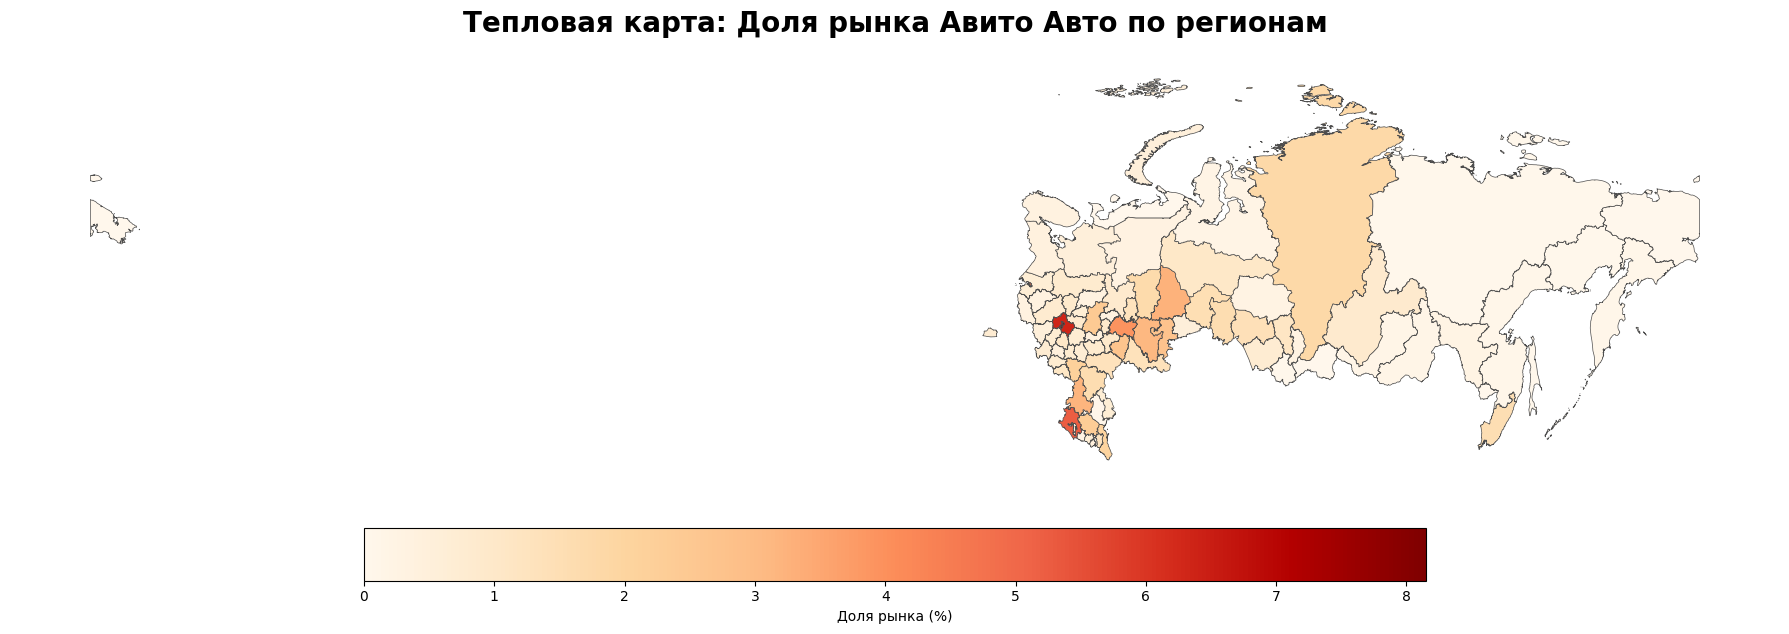

In [10]:
# 2. ТОТ САМЫЙ ГОТОВЫЙ СЛОВАРЬ МАППИНГА
region_mapping = {
    'Еврейская АО': 'Еврейская автономная область',
    'Кабардино-Балкария': 'Кабардино-Балкарская республика',
    'Калмыкия': 'Республика Калмыкия',
    'Карачаево-Черкесия': 'Карачаево-Черкесская республика',
    'Карелия': 'Республика Карелия',
    'Коми': 'Республика Коми',
    'Мордовия': 'Республика Мордовия',
    'Ненецкий АО': 'Ненецкий автономный округ',
    'Республика Алтай': 'Алтай',
    'Саха (Якутия)': 'Республика Саха (Якутия)',
    'Северная Осетия': 'Северная Осетия - Алания',
    'Удмуртия': 'Удмуртская республика',
    'Хакасия': 'Республика Хакасия',
    'Ханты-Мансийский АО': 'Ханты-Мансийский автономный округ - Югра',
    'Чеченская Республика': 'Чеченская республика',
    'Ямало-Ненецкий АО': 'Ямало-Ненецкий автономный округ'
    # 'Крым' и 'другой регион' не маппим, так как их нет на гео-карте
}

# 3. Применяем словарь: заменяем названия в нашей таблице Авито
df_stats['Регион_geo'] = df_stats['Регион'].replace(region_mapping)

# 4. Пространственный джоин
merged_map = gdf_russia.merge(df_stats, left_on='name', right_on='Регион_geo', how='left')

# Заполняем нулями регионы, где нет данных (чтобы они не вылетели в ошибку)
merged_map['Доля рынка (%)'] = merged_map['Доля рынка (%)'].fillna(0)

# 5. Отрисовка Тепловой Карты
fig, ax = plt.subplots(1, 1, figsize=(18, 10))

ax.axis('off')
ax.set_title('Тепловая карта: Доля рынка Авито Авто по регионам', 
             fontdict={'fontsize': 20, 'fontweight': 'bold'}, pad=20)

# Строим саму карту
merged_map.plot(
    column='Доля рынка (%)', 
    cmap='OrRd', # Цветовая палитра: от светло-желтого (0%) до темно-красного (Максимум)
    linewidth=0.5, 
    ax=ax, 
    edgecolor='0.3', 
    legend=True,
    legend_kwds={
        'label': "Доля рынка (%)",
        'orientation': "horizontal",
        'shrink': 0.6,
        'pad': 0.05
    },
    missing_kwds={'color': 'whitesmoke', 'hatch': '///'} # Нет данных = серая штриховка
)

plt.tight_layout()
plt.savefig('data/processed/avito_market_map_final.png', dpi=300, transparent=True)
print("✅ Карта успешно сгенерирована и сохранена в 'avito_market_map_final.png'")
plt.show()

In [14]:
# 1. Загружаем данные
df_stats = pd.read_excel('data/processed/region_distribution.xlsx')

# 2. Словарь маппинга (переписываем названия из Авито под твой GeoJSON)
region_mapping = {
    'Еврейская АО': 'Еврейская автономная область',
    'Кабардино-Балкария': 'Кабардино-Балкарская республика',
    'Калмыкия': 'Республика Калмыкия',
    'Карачаево-Черкесия': 'Карачаево-Черкесская республика',
    'Карелия': 'Республика Карелия',
    'Коми': 'Республика Коми',
    'Мордовия': 'Республика Мордовия',
    'Ненецкий АО': 'Ненецкий автономный округ',
    'Республика Алтай': 'Алтай',
    'Саха (Якутия)': 'Республика Саха (Якутия)',
    'Северная Осетия': 'Северная Осетия - Алания',
    'Удмуртия': 'Удмуртская республика',
    'Хакасия': 'Республика Хакасия',
    'Ханты-Мансийский АО': 'Ханты-Мансийский автономный округ - Югра',
    'Чеченская Республика': 'Чеченская республика',
    'Ямало-Ненецкий АО': 'Ямало-Ненецкий автономный округ',
    'Крым': 'Республика Крым' # Добавили Крым на случай, если в GeoJSON он есть
}

# КРИТИЧЕСКИЙ ШАГ: Создаем колонку Регион_geo, если ее еще нет
df_stats['Регион_geo'] = df_stats['Регион'].replace(region_mapping)

# Заполняем нули
df_stats['Доля рынка (%)'] = df_stats['Доля рынка (%)'].fillna(0)

# 3. Загружаем GeoJSON
with open('data/raw/russia.geojson.txt', 'r', encoding='utf-8') as f:
    russia_geojson = json.load(f)

# 4. Строим карту
fig = px.choropleth(
    df_stats,
    geojson=russia_geojson,
    locations='Регион_geo',        # ТЕПЕРЬ ЭТА КОЛОНКА ТОЧНО ЕСТЬ
    featureidkey='properties.name', 
    color='Доля рынка (%)',
    color_continuous_scale='Reds',
    hover_name='Регион',
    hover_data={'Регион_geo': False, 'Доля рынка (%)': True},
    title='Доля рынка Авито Авто по регионам'
)

# Настройка проекции (чтобы Россия не была плоской)
fig.update_geos(
    fitbounds="locations",
    visible=False,
    projection_type="conic conformal" 
)

fig.update_layout(
    title_x=0.5,
    margin={"r":0, "t":50, "l":0, "b":0}
)

# Сохраняем
fig.write_html('data/processed/avito_interactive_map.html')
print("✅ Карта готова. Если Крым был в GeoJSON, он закрасится.")

✅ Карта готова. Если Крым был в GeoJSON, он закрасится.


### Выделяем регионы

In [15]:
df = pd.read_csv('data/processed/processed_task1_total_liquidity.csv') 

# 2. Функция Ромчика
def assign_romchik_geo(region):
    if region == 'Москва': return 'Москва (Город)'
    if region == 'Московская область': return 'Московская область'
    if region == 'Санкт-Петербург': return 'Питер (Город)'
    if region == 'Ленинградская область': return 'Ленинградская область'
    
    if region in ['Дагестан', 'Чеченская Республика', 'Ингушетия', 'Кабардино-Балкария', 'Карачаево-Черкесия', 'Северная Осетия']:
        return 'Северный Кавказ'
        
    if region in ['Краснодарский край', 'Ростовская область', 'Ставропольский край', 'Адыгея', 'Крым', 'Севастополь', 'Калмыкия', 'Астраханская область', 'Волгоградская область']:
        return 'Юг РФ'
        
    if region in ['Приморский край', 'Хабаровский край', 'Амурская область', 'Сахалинская область', 'Камчатский край', 'Магаданская область', 'Саха (Якутия)', 'Чукотский АО', 'Еврейская АО', 'Забайкальский край', 'Бурятия']:
        return 'Дальний Восток'
        
    if region in ['Новосибирская область', 'Красноярский край', 'Кемеровская область', 'Омская область', 'Иркутская область', 'Алтайский край', 'Томская область', 'Хакасия', 'Республика Алтай', 'Тыва']:
        return 'Сибирь'
        
    if region in ['Свердловская область', 'Челябинская область', 'Тюменская область', 'Ханты-Мансийский АО', 'Ямало-Ненецкий АО', 'Курганская область']:
        return 'Урал'
        
    if region in ['Татарстан', 'Башкортостан', 'Самарская область', 'Нижегородская область', 'Саратовская область', 'Оренбургская область', 'Пермский край', 'Удмуртия', 'Пензенская область', 'Ульяновская область', 'Кировская область', 'Чувашия', 'Мордовия', 'Марий Эл']:
        return 'Поволжье'
        
    return 'Центр РФ'

# 3. Создаем новый столбец с регионами в ЭТОМ ЖЕ датасете
df['romchik_geo'] = df['region'].apply(assign_romchik_geo)

# 4. Сохраняем, чтобы ничего не потерять
df.to_csv('data/processed/processed_task1_with_geo.csv', index=False)
print("Столбец romchik_geo успешно добавлен в агрегированную базу!")

✅ Столбец romchik_geo успешно добавлен в агрегированную базу!


## Делаем бренды 

In [ ]:
file_path = 'data/processed/processed_task1_total_liquidity.csv'
df = pd.read_csv(file_path)

print(f"Загружена база: {len(df)} объявлений")

# ==========================================
# ШАГ 1: ГЕОГРАФИЯ (Логика Ромчика)
# ==========================================
def assign_romchik_geo(region):
    if region == 'Москва': return 'Москва (Город)'
    if region == 'Московская область': return 'Московская область'
    if region == 'Санкт-Петербург': return 'Питер (Город)'
    if region == 'Ленинградская область': return 'Ленинградская область'
    
    if region in ['Дагестан', 'Чеченская Республика', 'Ингушетия', 'Кабардино-Балкария', 'Карачаево-Черкесия', 'Северная Осетия']:
        return 'Северный Кавказ'
        
    if region in ['Краснодарский край', 'Ростовская область', 'Ставропольский край', 'Адыгея', 'Крым', 'Севастополь', 'Калмыкия', 'Астраханская область', 'Волгоградская область']:
        return 'Юг РФ'
        
    if region in ['Приморский край', 'Хабаровский край', 'Амурская область', 'Сахалинская область', 'Камчатский край', 'Магаданская область', 'Саха (Якутия)', 'Чукотский АО', 'Еврейская АО', 'Забайкальский край', 'Бурятия']:
        return 'Дальний Восток'
        
    if region in ['Новосибирская область', 'Красноярский край', 'Кемеровская область', 'Омская область', 'Иркутская область', 'Алтайский край', 'Томская область', 'Хакасия', 'Республика Алтай', 'Тыва']:
        return 'Сибирь'
        
    if region in ['Свердловская область', 'Челябинская область', 'Тюменская область', 'Ханты-Мансийский АО', 'Ямало-Ненецкий АО', 'Курганская область']:
        return 'Урал'
        
    if region in ['Татарстан', 'Башкортостан', 'Самарская область', 'Нижегородская область', 'Саратовская область', 'Оренбургская область', 'Пермский край', 'Удмуртия', 'Пензенская область', 'Ульяновская область', 'Кировская область', 'Чувашия', 'Мордовия', 'Марий Эл']:
        return 'Поволжье'
        
    return 'Центр РФ'

df['romchik_geo'] = df['region'].apply(assign_romchik_geo)
print("Гео-кластеры добавлены")

# ==========================================
# ШАГ 2: БРЕНДЫ (Логика Матвея)
# ==========================================
macro_brands_dict = {
    'Отечественные': ['lada (ваз)', 'газ', 'уаз', 'иж', 'москвич', 'lada', 'vaz'],
    'Корейский масс-маркет': ['kia', 'hyundai', 'ssangyong', 'daewoo'],
    'Японский масс-маркет': ['toyota', 'nissan', 'mazda', 'honda', 'mitsubishi', 'subaru', 'suzuki', 'datsun'],
    'Европейский масс-маркет': ['volkswagen', 'skoda', 'renault', 'peugeot', 'citroen', 'opel', 'fiat', 'seat'],
    'Премиум': ['mercedes-benz', 'bmw', 'audi', 'lexus', 'porsche', 'land rover', 'volvo', 'infiniti', 'jaguar', 'mini', 'genesis', 'jeep', 'cadillac'],
    'Китайские авто': ['chery', 'haval', 'geely', 'changan', 'exeed', 'omoda', 'faw', 'tank', 'jac', 'great wall', 'dongfeng', 'jetour', 'livan', 'gac'],
    'Американский масс-маркет': ['ford', 'chevrolet', 'dodge', 'chrysler']
}

# Разворачиваем словарь
brand_to_macro = {brand: macro for macro, brands in macro_brands_dict.items() for brand in brands}

# Маппим колонку brand, приводя всё к нижнему регистру
df['macro_brand'] = df['brand'].str.lower().str.strip().map(brand_to_macro).fillna('Прочие иномарки')
print("Макро-бренды добавлены")

# ==========================================
# ШАГ 3: СОХРАНЕНИЕ ФИНАЛЬНОГО ДАТАСЕТА
# ==========================================
final_path = 'data/processed/task1_final_features.csv'
df.to_csv(final_path, index=False)

print(f"ВСЁ ГОТОВО! Итоговый датасет сохранен в: {final_path}")
print("Именно этот файл теперь нужно использовать для выделения 6 снайперских ниш.")

📥 Загружена база: 358011 объявлений
Гео-кластеры добавлены
Макро-бренды добавлены
🚀 ВСЁ ГОТОВО! Итоговый датасет сохранен в: data/processed/task1_final_features.csv
Именно этот файл теперь нужно использовать для выделения 6 снайперских ниш.


## Выделяем сегменты

In [20]:
df_merged = pd.read_csv('data/processed/task1_final_features.csv')
current_year = 2026 

# ==========================================
# 1. БИННИНГ ЧИСЛОВЫХ ПРИЗНАКОВ
# ==========================================
bins_price = [0, 600_000, 1_500_000, 3_000_000, 6_000_000, 10_000_000, np.inf]
labels_price = ['Эконом (<600к)', 'Комфорт (600к-1.5м)', 'Комфорт+ (1.5м-3м)', 'Бизнес (3м-6м)', 'Премиум (6м-10м)', 'Люкс (>10м)']
df_merged['price_bin'] = pd.cut(df_merged['price'], bins=bins_price, labels=labels_price)

bins_mileage = [-1, 50_000, 100_000, 150_000, 250_000, 521_231]
labels_mileage = ['Свежее авто (0-50к)', 'Оптимальный б/у (50-100к)', 'Психологический барьер (100-150к)', 'Рабочая лошадка (150-250к)', 'Глубокое б/у (250-520к)']
df_merged['mileage_bin'] = pd.cut(df_merged['mileage'], bins=bins_mileage, labels=labels_mileage)

bins_year = [1900, current_year - 15, current_year - 7, current_year - 3, current_year + 1]
labels_year = ['Старше 15 лет (<2010)', 'Бюджет 7-15 лет (2010-2017)', 'Масс-маркет 3-7 лет (2018-2021)', 'Свежие <3 лет (2022-2025)']
df_merged['year_bin'] = pd.cut(df_merged['year'], bins=bins_year, labels=labels_year)

# ==========================================
# 2. ФОРМИРОВАНИЕ КОМБИНАЦИЙ (ТОЛЬКО ТОП-ФИЧИ)
# ==========================================
# Оставили только базу: Цена, Год, Пробег, Гео, Бренд, Состояние
features = [
    'price_bin', 'year_bin', 'mileage_bin', 
    'romchik_geo', 'macro_brand', 'condition'
]

# Ищем тройки (3 фичи из 6)
all_combos = list(combinations(features, 3))

# Бизнес-логика: сегмент обязан иметь географию И (привязку к цене ИЛИ бренду)
valid_combos = []
for combo in all_combos:
    if 'romchik_geo' in combo and ('price_bin' in combo or 'macro_brand' in combo):
        valid_combos.append(list(combo))

print(f"Всего валидных комбинаций для проверки: {len(valid_combos)}\n")

# ==========================================
# 3. ПОИСК И АГРЕГАЦИЯ (ЖЕСТКИЙ ПОРОГ)
# ==========================================
all_segments_results = []
THRESHOLD = 800 # Идеальный баланс между нишей и масс-маркетом

for combo in valid_combos:
    grouped = df_merged.groupby(combo, observed=True).agg(
        listings_count=('id', 'count'),
        liquidity=('total_contacts', 'median') 
    ).reset_index()
    
    # Отсекаем всё, что меньше порога
    valid_segments = grouped[grouped['listings_count'] >= THRESHOLD].copy()
    
    if not valid_segments.empty:
        valid_segments['segment_portrait'] = valid_segments[combo].astype(str).agg(' | '.join, axis=1)
        res = valid_segments[['segment_portrait', 'listings_count', 'liquidity']].copy()
        res['used_features'] = ' + '.join(combo)
        all_segments_results.append(res)

# ==========================================
# 4. ФИНАЛЬНАЯ СБОРКА И ВЫГРУЗКА
# ==========================================
if all_segments_results:
    final_report = pd.concat(all_segments_results, ignore_index=True)
    final_report = final_report.drop_duplicates(subset=['segment_portrait'])
    final_report = final_report.sort_values(by='liquidity', ascending=False).reset_index(drop=True)
    
    final_report['liquidity'] = final_report['liquidity'].round(1)
    final_report['listings_count'] = final_report['listings_count'].astype(int)
    
    final_report.to_csv('data/processed/FINAL_PRODUCT_SEGMENTS.csv', index=False)
    
    n_total = len(final_report)
    print(f"✅ Успешно! Найдено плотных продуктовых сегментов (>{THRESHOLD} авто): {n_total}")
    print("Файл сохранен: 'data/processed/FINAL_PRODUCT_SEGMENTS.csv'\n")
    
    cols_to_show = ['segment_portrait', 'liquidity', 'listings_count']
    
    print("🔥 Топ-5 ГОРЯЧИХ сегментов (Высокая органика):")
    display(final_report[cols_to_show].head(5))
    
    print("\n💀 Топ-5 МЕРТВЫХ сегментов (Зона внедрения VAS):")
    display(final_report[cols_to_show].tail(5))

else:
    print(f"Ни один сегмент не прошел порог в {THRESHOLD} объявлений. Проверьте данные.")

Всего валидных комбинаций для проверки: 7

✅ Успешно! Найдено плотных продуктовых сегментов (>800 авто): 661
Файл сохранен: 'data/processed/FINAL_PRODUCT_SEGMENTS.csv'

🔥 Топ-5 ГОРЯЧИХ сегментов (Высокая органика):


,segment_portrait,liquidity,listings_count
0,Старше 15 лет (<2010) | Северный Кавказ | Премиум,18.0,945
1,Эконом (<600к) | Москва (Город) | Корейский ма...,15.0,993
2,Старше 15 лет (<2010) | Москва (Город) | Прочи...,14.0,931
3,Эконом (<600к) | Бюджет 7-15 лет (2010-2017) |...,14.0,1004
4,Старше 15 лет (<2010) | Московская область | П...,14.0,1262



💀 Топ-5 МЕРТВЫХ сегментов (Зона внедрения VAS):


,segment_portrait,liquidity,listings_count
656,Комфорт+ (1.5м-3м) | Масс-маркет 3-7 лет (2018...,0.0,1967
657,Комфорт (600к-1.5м) | Масс-маркет 3-7 лет (201...,0.0,887
658,Бизнес (3м-6м) | Масс-маркет 3-7 лет (2018-202...,0.0,955
659,Бизнес (3м-6м) | Дальний Восток | Не битый,0.0,1118
660,Комфорт+ (1.5м-3м) | Бюджет 7-15 лет (2010-201...,0.0,1965
